# ANALYSIS OF CAPSULE SIZE

In [ ]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import tifffile as tiff

try:
    import nd2
    ND2_AVAILABLE = True
except ImportError:
    ND2_AVAILABLE = False
    print("Warning: nd2 package not installed. ND2 files cannot be opened.")

from pathlib import Path
from ipywidgets import interact
from skimage.draw import polygon2mask
from skimage.measure import label, regionprops
from skimage.morphology import white_tophat, black_tophat, disk
from IPython.display import display
from skimage.filters import threshold_otsu


### Load the images from folder

In [39]:
def load_image(file_path): #Load nd2 or tiff imagees and return 2D for display
    ext = file_path.suffix.lower()

    if ext == ".nd2":
        if not ND2_AVAILABLE:
            raise ImportError("Please install nd2 package.")

        img = nd2.imread(str(file_path))

    elif ext in [".tif", ".tiff"]:
        img = tiff.imread(str(file_path))

    else:
        return None  # Reduce multidimensional data to something displayable
    while img.ndim > 2:
        img = img[0]

    return img

In [40]:
# Ask user for folder
folder = input("Enter folder path containing ND2/TIFF files: ").strip()

folder_path = Path(folder)

if not folder_path.exists():
    raise FileNotFoundError(f"Folder not found: {folder}")

Enter folder path containing ND2/TIFF files:  F:/Users/kanak/Desktop/Kanak_Data/CRPP/Optical Microscope/20260424/DwSA


Found 12 files.


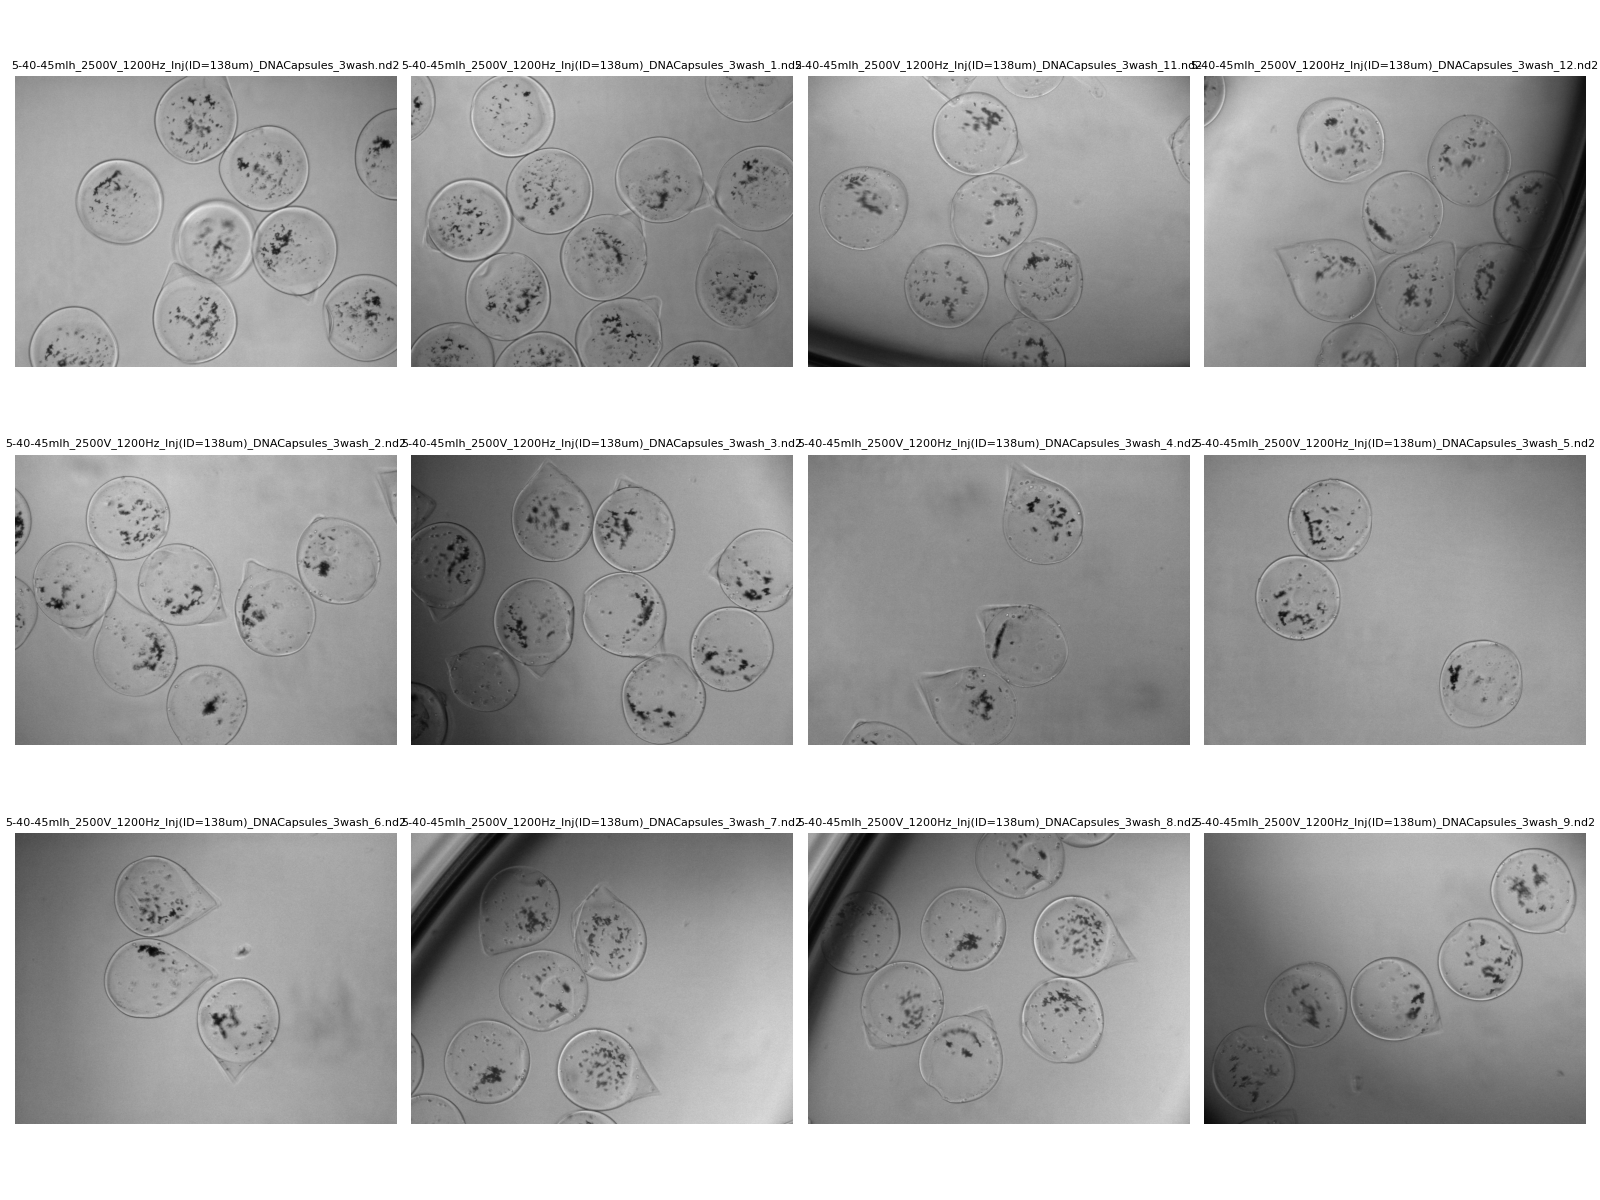

In [41]:
# Find files
image_files = sorted(
    list(folder_path.glob("*.nd2")) +
    list(folder_path.glob("*.tif")) +
    list(folder_path.glob("*.tiff"))
)

if len(image_files) == 0:
    print("No ND2 or TIFF files found.")
else:
    print(f"Found {len(image_files)} files.")

    # Grid dimensions
    n_images = len(image_files)
    n_cols = min(4, n_images)
    n_rows = math.ceil(n_images / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4*n_cols, 4*n_rows)
    )
    if n_images == 1:
        axes = np.array([axes])

    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for i, file_path in enumerate(image_files):

        try:
            img = load_image(file_path)

            axes[i].imshow(img, cmap="gray")
            axes[i].set_title(file_path.name, fontsize=8)
            axes[i].axis("off")

        except Exception as e:
            axes[i].text(
                0.5,
                0.5,
                f"Error\n{str(e)}",
                ha="center",
                va="center"
                 )
            axes[i].set_title(file_path.name, fontsize=8)

    plt.tight_layout()
    plt.show()
  

In [42]:
plt.close('all') #to remove figures from memory
print(plt.get_fignums())

[]


In [43]:
images = []  # store all loaded images

for i, file_path in enumerate(image_files):

    try:
        img = load_image(file_path)

        images.append(img)   # <-- save image here

        axes[i].imshow(img, cmap="gray")
        axes[i].set_title(f"{i}: {file_path.name}", fontsize=8)
        axes[i].axis("off")

    except Exception as e:
        axes[i].text(
            0.5,
            0.5,
            f"Error\n{str(e)}",
            ha="center",
            va="center"
        )
        axes[i].set_title(file_path.name, fontsize=8)

### Enhance the contrast 

In [8]:
images = []
enhanced_images = []

for file_path in image_files:

    img = load_image(file_path)

    # convert to uint8 if needed
    if img.dtype != np.uint8:
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # CLAHE contrast enhancement
    clahe = cv2.createCLAHE(
        clipLimit=3.0,
        tileGridSize=(8, 8)
    )
    enhanced = clahe.apply(img)

    images.append(img)
    enhanced_images.append(enhanced)

print("Original images:", len(images))
print("Enhanced images:", len(enhanced_images))

Original images: 12
Enhanced images: 12


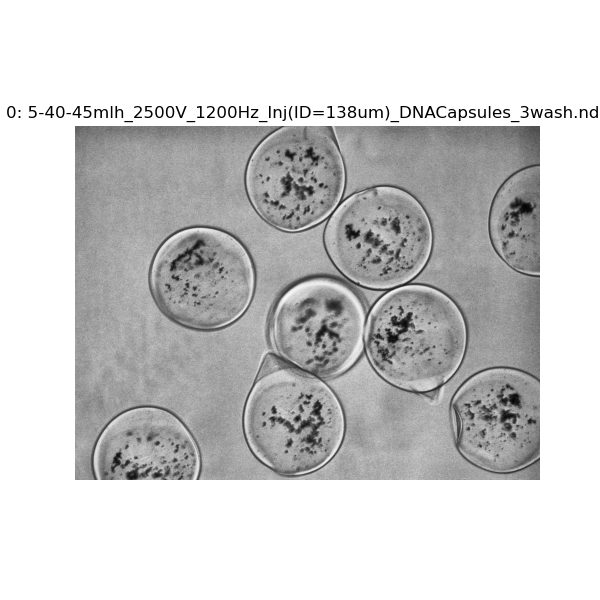

In [61]:
from IPython.display import display

current_idx = 0

# -----------------------------
# CREATE FIGURE ONCE
# -----------------------------
fig, ax = plt.subplots(figsize=(6,6))
img_artist = ax.imshow(enhanced_images[0], cmap="gray")
ax.axis("off")
title = ax.set_title("")

# -----------------------------
# UPDATE IMAGE
# -----------------------------
def update_display():
    img_artist.set_data(enhanced_images[current_idx])
    title.set_text(f"{current_idx}: {image_files[current_idx].name}")
    fig.canvas.draw_idle()

# -----------------------------
# BUTTONS
# -----------------------------
btn_prev = widgets.Button(description=" Previous", layout=widgets.Layout(width='120px'))
btn_next = widgets.Button(description="Next ", layout=widgets.Layout(width='120px'))

def prev(_):
    global current_idx
    if current_idx > 0:
        current_idx -= 1
        update_display()

def next(_):
    global current_idx
    if current_idx < len(enhanced_images) - 1:
        current_idx += 1
        update_display()

btn_prev.on_click(prev)
btn_next.on_click(next)

# -----------------------------
# SHOW UI
# -----------------------------
update_display()

display(widgets.HBox([btn_prev, btn_next]))

In [62]:
plt.close('all') #close to save memory
print(plt.get_fignums())

[]


### Subtract Backgrond

In [63]:
def subtract_background(image, radius=10, light_bg=False):
    str_el = disk(radius)

    if light_bg:
        return black_tophat(image, str_el)
    else:
        return white_tophat(image, str_el)


In [64]:
# Apply background subtraction to all enhanced images
background_subtracted_images = []

for img in enhanced_images:
    bg_subtracted = subtract_background(
        img,
        radius=10,      # adjust as needed
        light_bg=True  # set True if objects are dark on bright background
    )
    background_subtracted_images.append(bg_subtracted)

print("Background-subtracted images:", len(background_subtracted_images))

Background-subtracted images: 12


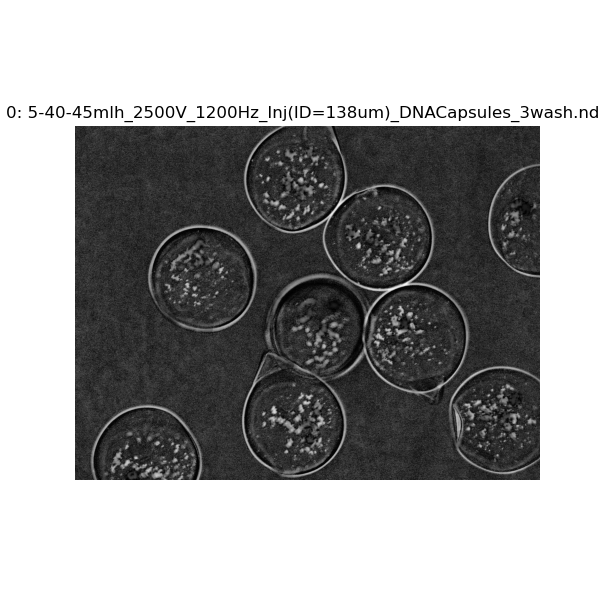

In [65]:
from IPython.display import display

current_idx = 0

# -----------------------------
# CREATE FIGURE ONCE
# -----------------------------
fig, ax = plt.subplots(figsize=(6,6))
img_artist = ax.imshow(background_subtracted_images[0], cmap="gray")
ax.axis("off")
title = ax.set_title("")

# -----------------------------
# UPDATE IMAGE
# -----------------------------
def update_display():
    img_artist.set_data(background_subtracted_images[current_idx])
    title.set_text(f"{current_idx}: {image_files[current_idx].name}")
    fig.canvas.draw_idle()

# -----------------------------
# BUTTONS
# -----------------------------
btn_prev = widgets.Button(description=" Previous", layout=widgets.Layout(width='120px'))
btn_next = widgets.Button(description="Next ", layout=widgets.Layout(width='120px'))

def prev(_):
    global current_idx
    if current_idx > 0:
        current_idx -= 1
        update_display()

def next(_):
    global current_idx
    if current_idx < len(background_subtracted_images) - 1:
        current_idx += 1
        update_display()

btn_prev.on_click(prev)
btn_next.on_click(next)

# -----------------------------
# SHOW UI
# -----------------------------
update_display()

display(widgets.HBox([btn_prev, btn_next]))

In [66]:
plt.close('all')
print(plt.get_fignums())

[]


### Threshold Images

In [67]:
thresholded_images = []

for img in background_subtracted_images:

    thresh = threshold_otsu(img)

    binary = img > thresh

    # Convert to uint8 (0 and 255) for display/saving
    binary = (binary * 255).astype("uint8")

    thresholded_images.append(binary)

print("Thresholded images:", len(thresholded_images))

Thresholded images: 12


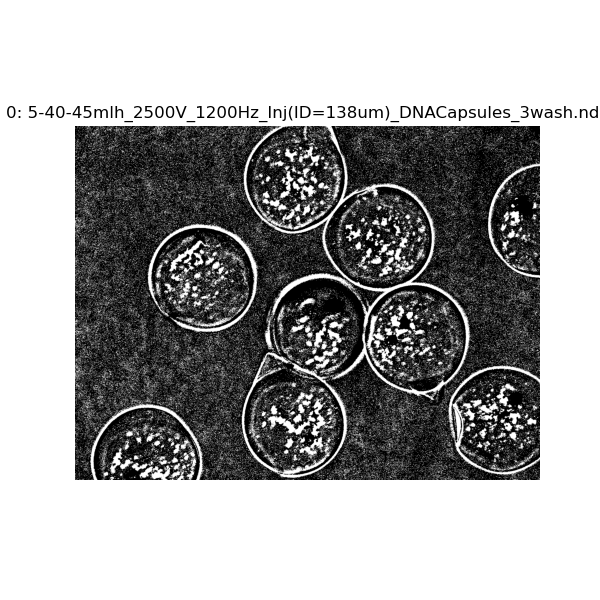

In [68]:
from IPython.display import display

current_idx = 0

# -----------------------------
# CREATE FIGURE ONCE
# -----------------------------
fig, ax = plt.subplots(figsize=(6,6))
img_artist = ax.imshow(thresholded_images[0], cmap="gray")
ax.axis("off")
title = ax.set_title("")

# -----------------------------
# UPDATE IMAGE
# -----------------------------
def update_display():
    img_artist.set_data(thresholded_images[current_idx])
    title.set_text(f"{current_idx}: {image_files[current_idx].name}")
    fig.canvas.draw_idle()

# -----------------------------
# BUTTONS
# -----------------------------
btn_prev = widgets.Button(description=" Previous", layout=widgets.Layout(width='120px'))
btn_next = widgets.Button(description="Next ", layout=widgets.Layout(width='120px'))

def prev(_):
    global current_idx
    if current_idx > 0:
        current_idx -= 1
        update_display()

def next(_):
    global current_idx
    if current_idx < len(thresholded_images) - 1:
        current_idx += 1
        update_display()

btn_prev.on_click(prev)
btn_next.on_click(next)

# -----------------------------
# SHOW UI
# -----------------------------
update_display()

display(widgets.HBox([btn_prev, btn_next]))

In [69]:
plt.close('all')
print(plt.get_fignums())

[]


### Creating Polygon Shapes to Make Masks

Button(description='Next', style=ButtonStyle())

Button(description='Previous', style=ButtonStyle())

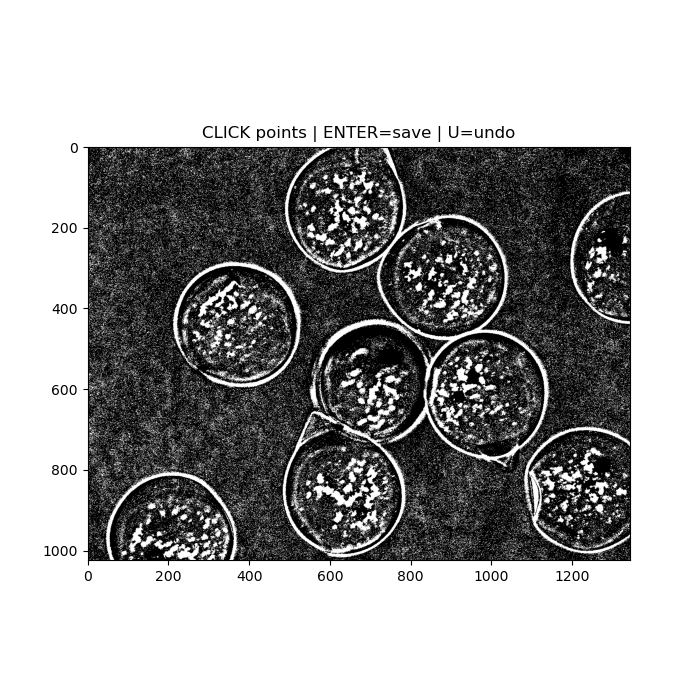

In [75]:
%matplotlib widget



# -----------------------------
# STORAGE
# -----------------------------
polygons = {}
current_idx = 0
current_points = []
drawing = True  # IMPORTANT: state flag

# -----------------------------
# FIGURE
# -----------------------------
fig, ax = plt.subplots(figsize=(7,7))

img_artist = ax.imshow(thresholded_images[0], cmap='gray')
ax.set_title("CLICK points | ENTER=save | U=undo")

# live display
live_line, = ax.plot([], [], color='yellow', linewidth=2)
live_scatter = ax.scatter([], [], c='yellow', s=40)

# -----------------------------
# REFRESH DRAWING
# -----------------------------
def refresh():
    if len(current_points) > 0:
        pts = np.array(current_points)
        live_line.set_data(pts[:,0], pts[:,1])
        live_scatter.set_offsets(pts)
    else:
        live_line.set_data([], [])
        live_scatter.set_offsets(np.empty((0,2)))

    fig.canvas.draw_idle()

# -----------------------------
# CLICK → ADD POINT
# -----------------------------
def on_click(event):
    if event.inaxes != ax:
        return

    if not drawing:
        return

    current_points.append([event.xdata, event.ydata])
    refresh()

fig.canvas.mpl_connect('button_press_event', on_click)

# -----------------------------
# KEYBOARD CONTROL
# -----------------------------
def on_key(event):
    global current_points, drawing

    # UNDO
    if event.key == "u":
        if current_points:
            current_points.pop()
            refresh()

    # SAVE (ENTER)
    if event.key == "enter":
        if len(current_points) < 3:
            print("Need at least 3 points")
            return

        poly = np.array(current_points).copy()

        polygons.setdefault(current_idx, []).append(poly)

        print(f"Saved polygon for image {current_idx}")

        # RESET EVERYTHING (CRITICAL FIX)
        current_points = []
        refresh()
        draw_polygons()

fig.canvas.mpl_connect('key_press_event', on_key)

# -----------------------------
# DRAW SAVED POLYGONS
# -----------------------------
def draw_polygons():

    # remove old red lines only
    for line in ax.lines[:]:
        if line != live_line:
            line.remove()

    if current_idx in polygons:
        for poly in polygons[current_idx]:
            ax.plot(poly[:,0], poly[:,1], 'r-')

    fig.canvas.draw_idle()

# -----------------------------
# SWITCH IMAGE (FULL RESET)
# -----------------------------
def go_to(idx):

    global current_idx, current_points

    current_idx = idx
    slider.value = idx

    current_points = []

    img_artist.set_data(thresholded_images[idx])
    ax.set_title(f"Image {idx} | CLICK | ENTER save | U undo")

    live_line.set_data([], [])
    live_scatter.set_offsets(np.empty((0,2)))

    draw_polygons()

# -----------------------------
# NEXT / PREV
# -----------------------------
def next_img(_=None):
    if current_idx < len(thresholded_images) - 1:
        go_to(current_idx + 1)

def prev_img(_=None):
    if current_idx > 0:
        go_to(current_idx - 1)

# -----------------------------
# BUTTONS
# -----------------------------
btn_next = widgets.Button(description="Next")
btn_prev = widgets.Button(description="Previous")

btn_next.on_click(next_img)
btn_prev.on_click(prev_img)

display(btn_next, btn_prev)

In [71]:
masks = {}

def build_mask(idx):

    h, w = thresholded_images[idx].shape

    mask = np.zeros((h, w), dtype=bool)

    if idx in polygons:

        for poly in polygons[idx]:

            poly_mask = polygon2mask((h, w), poly)

            mask = mask | poly_mask   # combine all shapes

    masks[idx] = mask

    return mask

In [72]:
def show_mask(idx):

    mask = build_mask(idx)

    fig, ax = plt.subplots(1, 2, figsize=(10,5))

    ax[0].imshow(thresholded_images[idx], cmap='gray')
    ax[0].set_title("Original")
    ax[0].axis("off")

    ax[1].imshow(mask, cmap='gray')
    ax[1].set_title("Mask")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()

In [73]:
widgets.interact(show_mask,
    idx=widgets.IntSlider(
        min=0,
        max=len(thresholded_images)-1,
        step=1,
        value=0
    )
)

interactive(children=(IntSlider(value=0, description='idx', max=11), Output()), _dom_classes=('widget-interact…

<function __main__.show_mask(idx)>

### Calculation of Area and Diameter

In [74]:
def get_pixel_size_um(file_path): #get pixel size for nd2 files
    import nd2   #need to change if tiff
    with nd2.ND2File(file_path) as f:
        ps = f.voxel_size()
        return ps[1], ps[2]   # (y, x)

def build_mask(idx):    # Make mask from polygon
    h, w = thresholded_images[idx].shape
    mask = np.zeros((h, w), dtype=bool)

    if idx in polygons:
        for poly in polygons[idx]:
            mask |= polygon2mask((h, w), poly)

    return mask


all_rows = []  #analyze

for idx, file_path in enumerate(image_files):

    try:
        mask = build_mask(idx)

        labeled = label(mask)
        props = regionprops(labeled)

        pixel_y, pixel_x = get_pixel_size_um(file_path)

        for p in props:

            area_um2 = p.area * pixel_y * pixel_x
            diameter_um = p.equivalent_diameter * ((pixel_y + pixel_x) / 2)

            all_rows.append([
                idx,           # Image_ID
                p.label,       # Shape_ID
                area_um2,      # Area
                diameter_um    # Diameter
            ])

    except Exception as e:
        print(f"Error in image {idx}: {e}")


df = pd.DataFrame(all_rows, columns=[     #create table
    "Image_ID",
    "Shape_ID",
    "Area_um2",
    "Diameter_um"
])

print("\n=== FULL TABLE ===")
display(df)


print("\n=== SUMMARY (ALL IMAGES COMBINED) ===")  #display summary
print(f"Total capsules: {len(df)}")

print(f"Mean Area      : {df['Area_um2'].mean():.3f} ± {df['Area_um2'].std():.3f} µm²")
print(f"Mean Diameter  : {df['Diameter_um'].mean():.3f} ± {df['Diameter_um'].std():.3f} µm")


=== FULL TABLE ===


,Image_ID,Shape_ID,Area_um2,Diameter_um
0,0,1,64113.462373,285.988131



=== SUMMARY (ALL IMAGES COMBINED) ===
Total capsules: 1
Mean Area      : 64113.462 ± nan µm²
Mean Diameter  : 285.988 ± nan µm


### Save Excel File

In [81]:
# folder where images come from
output_folder = folder_path  # same as your image folder

# file name
output_file = os.path.join(output_folder, "capsule_analysis.xlsx")

# save dataframe
df.to_excel(output_file, index=False)

print(f"Saved Excel file at:\n{output_file}")

Saved Excel file at:
F:\Users\kanak\Desktop\Kanak_Data\CRPP\Optical Microscope\20260424\DwSA\capsule_analysis.xlsx
